<a href="https://colab.research.google.com/github/Soham12Sawant/M_L_Lab/blob/main/LDA_Wine_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
X = wine.data.features
y = wine.data.targets

# metadata
print(wine.metadata)

# variable information
print(wine.variables)


{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

In [4]:
y = y.values.ravel()

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

model_orig = LogisticRegression(max_iter=1000)
model_orig.fit(X_train, y_train)

y_pred_orig = model_orig.predict(X_test)

print("Original Data:")
print("Accuracy:", accuracy_score(y_test, y_pred_orig))
print("F1 Score:", f1_score(y_test, y_pred_orig, average='weighted'))

Original Data:
Accuracy: 0.9814814814814815
F1 Score: 0.9815058961400425


In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_2 = LinearDiscriminantAnalysis(n_components=2)
X_lda_2 = lda_2.fit_transform(X_scaled, y)

In [8]:
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
    X_lda_2, y, test_size=0.3, random_state=42, stratify=y
)

model_lda = LogisticRegression(max_iter=1000)
model_lda.fit(X_train_lda, y_train_lda)

y_pred_lda = model_lda.predict(X_test_lda)

print("\nLDA (2D):")
print("Accuracy:", accuracy_score(y_test_lda, y_pred_lda))
print("F1 Score:", f1_score(y_test_lda, y_pred_lda, average='weighted'))


LDA (2D):
Accuracy: 1.0
F1 Score: 1.0


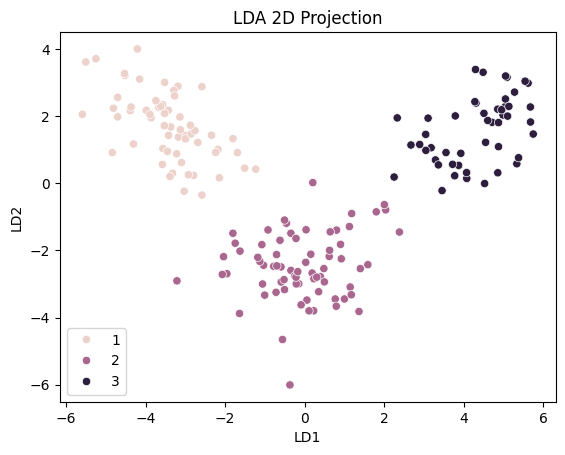

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.scatterplot(x=X_lda_2[:,0], y=X_lda_2[:,1], hue=y)
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

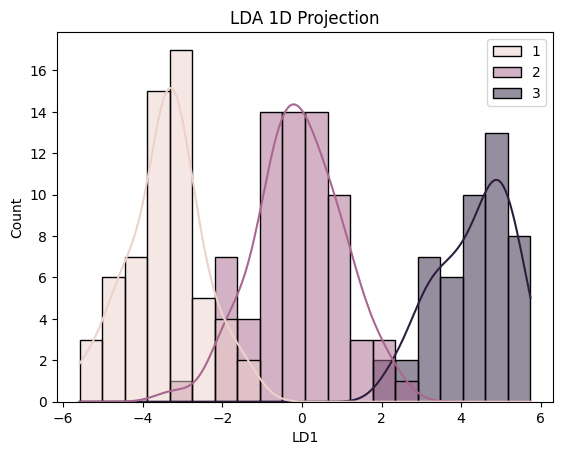

In [10]:
lda_1 = LinearDiscriminantAnalysis(n_components=1)
X_lda_1 = lda_1.fit_transform(X_scaled, y)

plt.figure()
sns.histplot(x=X_lda_1[:,0], hue=y, bins=20, kde=True)
plt.title("LDA 1D Projection")
plt.xlabel("LD1")
plt.show()

In [11]:
import pandas as pd

df_proj = pd.DataFrame({
    "SampleId": range(len(X_lda_2)),
    "LD1": X_lda_2[:,0],
    "LD2": X_lda_2[:,1],
    "Class": y
})

df_proj.to_csv("lda_projection.csv", index=False)